# Практическое занятие №4: Полный цикл предобработки данных

## Задание

1. Загрузить данные из внешнего источника (CSV-файл).
2. Провести первичный анализ структуры и качества данных.
3. Обработать пропущенные значения различными методами.
4. Выявить и удалить дубликаты.
5. Обнаружить и обработать выбросы.
6. Создать новые признаки на основе существующих.
7. Отфильтровать ненужные данные и сохранить результат.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

/home/ub/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


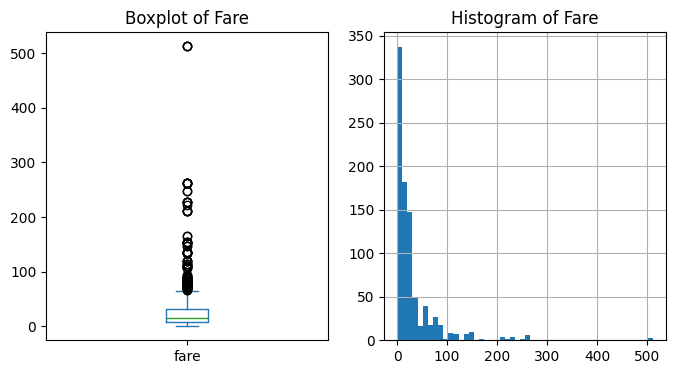

Предобработка завершена. Размер итогового датасета: (771, 17)


In [3]:
# Загрузка
df = sns.load_dataset('titanic')

# Удаление столбца с большим числом пропусков
df.drop(columns=['deck'], inplace=True)

# Удаление строк с пропусками в embarked
df.dropna(subset=['embarked'], inplace=True)

# Заполнение возраста медианой по группе
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))

# Проверка выбросов (точки на графике)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
df['fare'].plot(kind='box')
plt.title('Boxplot of Fare')
plt.subplot(1,2,2)
df['fare'].hist(bins=50)
plt.title('Histogram of Fare')
plt.show()

# Удаление дубликатов
df.drop_duplicates(inplace=True)

# Создание новых признаков
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['age_group'] = df['age'].apply(lambda age: 'child' if age < 18 else ('adult'
if age < 60 else 'elderly'))
# Сохранение
df.to_csv('titanic_cleaned.csv', index=False)

print("Предобработка завершена. Размер итогового датасета:", df.shape)